In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [70]:
X, y_true = make_blobs(n_samples=100000, centers=5, cluster_std=5, random_state=42)
# X, y_true = make_blobs(n_samples=500, centers=3, cluster_std=4, random_state=42)

In [71]:
df = pd.DataFrame(X, columns=['Feature_1', 'Feature_2'])

In [73]:
df

,Feature_1,Feature_2
0,-6.696642,9.724097
1,-6.710456,6.151245
2,-8.779311,4.019604
3,-3.668790,9.363819
4,-4.130914,-5.973099
...,...,...
99995,-5.265688,-12.815586
99996,12.866311,0.126512
99997,-2.474379,-0.382469
99998,6.686501,-8.110350


In [74]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

In [75]:
inertia = []  # WCSS
K_range = range(1, 11)

In [76]:
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)


In [77]:
inertia

[200000.00000000015,
 129982.68343613851,
 77719.93555348049,
 61918.15085617387,
 51668.1677125112,
 44217.63294291205,
 39118.48884181972,
 34627.760287308854,
 31260.16372289485,
 28286.60915056977]

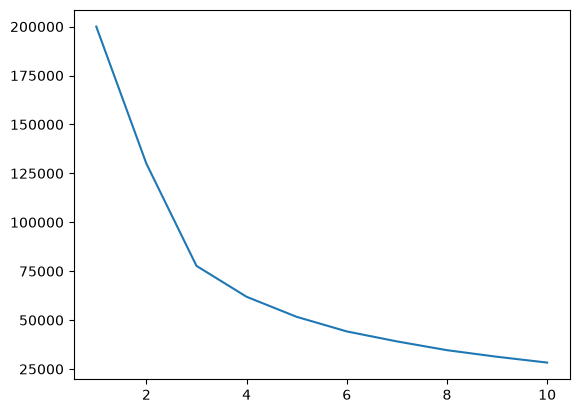

In [78]:
plt.plot(K_range,inertia)

In [79]:
kmeans_final = KMeans(n_clusters=3, random_state=42)

In [80]:
cluster_labels = kmeans_final.fit_predict(X_scaled)

In [81]:
df['cluster'] = cluster_labels

<Axes: xlabel='Feature_1', ylabel='Feature_2'>

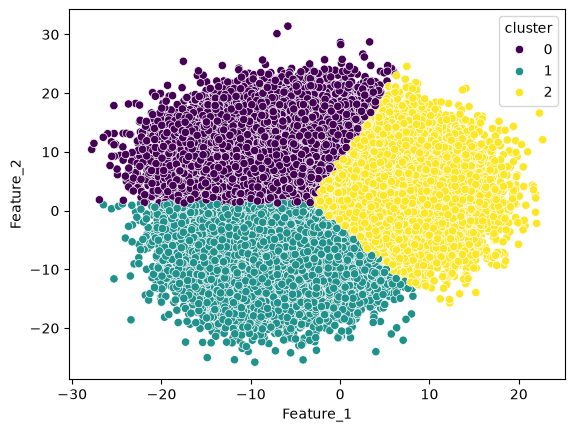

In [82]:
sns.scatterplot(x=df['Feature_1'],
                y=df['Feature_2'],
                hue=df['cluster'],
                palette='viridis')